In [ ]:
# 最重要的是在本panel 上选择 Python3.11.15（pixi:scanpy-env）, 在右上角也要选择 Python3.11.15 pixi:scanpy-env） <<<======

In [1]:
import os
os.environ["NUMBA_CACHE_DIR"] = "/tmp/numba_cache"  # Linux/macOS
# Windows 可用: r"C:\temp\numba_cache"


In [1]:
#import numba, vmlite, sys
import numba,llvmlite , sys
print(sys.executable)
print(numba.__version__, llvmlite.__version__)
print(numba.__file__)

/home/gao/.conda/envs/qc_env/bin/python
0.65.0 0.47.0
/home/gao/.conda/envs/qc_env/lib/python3.14/site-packages/numba/__init__.py


In [ ]:
# 1. 创建新的 conda 环境（使用 mamba 加速解析）
mamba create -n scanpy_analysis python=3.10

# 2. 激活环境
conda activate scanpy_analysis

# 3. 安装核心依赖（使用 conda-forge 和 bioconda）
mamba install -c conda-forge -c bioconda \
    scanpy anndata pandas numpy scikit-learn \
    matplotlib seaborn numba jupyterlab

# 4. 安装 omicverse（根据之前的搜索结果）
mamba install -c conda-forge omicverse

# 5. 安装 ipykernel 以便在 Jupyter 中使用
pip install ipykernel

# 6. 注册 kernel
python -m ipykernel install --user --name scanpy_analysis --display-name "Python (scanpy_analysis)"

In [4]:
import scanpy as sc

In [7]:
import warnings
warnings.filterwarnings("ignore")

import scanpy as sc
import omicverse as ov
import pandas as pd

ModuleNotFoundError: No module named 'omicverse'

In [3]:
import omicverse as ov
ov.ov_plot_set()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 PyTorch not available - GPU detection skipped

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.9   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [3]:
!pwd 

/home/zhen/GZ_Projects_2026/04_SC_Analysis/scanpy_path



第一步，我们使用scanpy加载数据集

In [ ]:
# 4) 读取
adata = sc.read_10x_h5("filtered_feature_bc_matrix.h5")
# #adata=ov.utils.pancreas() # 载入示例数据集 <<<<============== Another good dataset

In [27]:
adata

AnnData object with n_obs × n_vars = 16934 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

**Before modification:** `The following 9 cells are used too check the data shape and quality.`  
**Reason:** `too` is incorrect here; it should be `to` after `used`, so spell/grammar check marks it with a red wavy underline.

In [5]:
# 修改说明: Imports for multi-angle AnnData description cells
import numpy as np
import pandas as pd
from scipy import sparse

In [7]:
# 修改说明: 01 basic shape, matrix type, nnz (number of non-zero elements), and sparsity
def f01_basic_shape_and_sparsity(adata):
    n_cells, n_genes = adata.n_obs, adata.n_vars
    X = adata.X
    # nnz is the number of non-zero elements
    is_sparse = sparse.issparse(X)
    nnz = X.nnz if is_sparse else np.count_nonzero(X) 
    sparsity = 1 - (nnz / (n_cells * n_genes)) # sparsity is the ratio of non-zero elements to total elements
    # in fact, this data has about 97% sparsity, that means 3% genes are dected in each cell on average. 

    out = pd.Series({
        "n_cells": n_cells,
        "n_genes": n_genes,
        "matrix_type": "sparse" if is_sparse else "dense",
        "nnz": int(nnz),
        "sparsity": float(sparsity),
    })
    display(out)
    return out

basic_stats = f01_basic_shape_and_sparsity(adata)


n_cells           16934
n_genes           36601
matrix_type      sparse
nnz            17937794
sparsity       0.971059
dtype: object

ravel 这个名字来自英文短语 “to ravel out”，意思接近“理开、展开”。
在 NumPy 里它表示把多维结构“展开”成一维，所以函数叫 ravel()。语义上和 flatten 很像，但 ravel() 更强调“view/展开视图”（可能不复制内存），而 flatten() 通常会复制。

libsize means library size  <=== (total counts per cell)

In [8]:
# 修改说明: 02 per-cell and per-gene detection/count statistics
def f02_cell_gene_level_stats(adata):
    X = adata.X

    if sparse.issparse(X):
        # 修改说明: Count detected genes (>0) per cell, then flatten to 1D array
        # 修改说明: axis=1 means count by row (each row is one cell)
        cell_nnz = np.asarray((X > 0).sum(axis=1)).ravel()
        gene_nnz = np.asarray((X > 0).sum(axis=0)).ravel()
        # 修改说明: Sum expression counts per cell, then flatten to 1D array
        # 修改说明: axis=1 means sum by row (each row is one cell)
        libsize = np.asarray(X.sum(axis=1)).ravel()
    else:
        cell_nnz = (X > 0).sum(axis=1)
        gene_nnz = (X > 0).sum(axis=0)
        libsize = X.sum(axis=1)

    stats = pd.DataFrame({
        "metric": ["genes_per_cell", "cells_per_gene", "counts_per_cell"],
        "median": [np.median(cell_nnz), np.median(gene_nnz), np.median(libsize)],
        "mean": [np.mean(cell_nnz), np.mean(gene_nnz), np.mean(libsize)],
        "p05": [np.quantile(cell_nnz, 0.05), np.quantile(gene_nnz, 0.05), np.quantile(libsize, 0.05)],
        "p95": [np.quantile(cell_nnz, 0.95), np.quantile(gene_nnz, 0.95), np.quantile(libsize, 0.95)],
    })
    display(stats)
    return stats

level_stats = f02_cell_gene_level_stats(adata)


,metric,median,mean,p05,p95
0,genes_per_cell,812.0,1059.276839,203.0,2883.35
1,cells_per_gene,36.0,490.090271,0.0,2674.00
2,counts_per_cell,1156.0,1862.777954,241.0,5898.05


现在只有 cell index，没有 cell-level annotations。
常见于刚读入表达矩阵、还没跑 QC 注释步骤的阶段。

后续需要先往 obs 写入列（如 total_counts, n_genes_by_counts, pct_counts_mt 等），再做缺失值检查才有意义

可先看： The next 2 cells 

In [17]:
adata.obs.head()      # 会是空表（只有 index）

""
AAACAGCCAAGCTTAT-1
AAACAGCCATAGCTTG-1
AAACAGCCATGAAATG-1
AAACAGCCATGTTTGG-1
AAACATGCAACGTGCT-1


In [16]:
adata.var.head()      # 通常会有基因信息列


,gene_ids,feature_types,genome,interval
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38,chr1:29553-30267
FAM138A,ENSG00000237613,Gene Expression,GRCh38,chr1:36080-36081
OR4F5,ENSG00000186092,Gene Expression,GRCh38,chr1:65418-69055
AL627309.1,ENSG00000238009,Gene Expression,GRCh38,chr1:120931-133723
AL627309.3,ENSG00000239945,Gene Expression,GRCh38,chr1:91104-91105


In [11]:
print(adata.obs.shape)
print((adata.obs.isna().sum() > 0).sum())   # 有缺失的列数
display(adata.obs.isna().sum().sort_values(ascending=False).head(10))

# 检查“伪缺失”文本
for c in adata.obs.columns:
    s = adata.obs[c].astype(str).str.strip().str.lower()
    n = s.isin(["", "na", "none", "null", "nan", "unknown"]).sum()
    if n > 0:
        print(c, n)


(16934, 0)
0


Series([], dtype: float64)

上面结果：
返回 0 是“真空结果”：

没有列可统计
自然“有缺失的列数”也是 0
这不代表“数据很完整”，而是代表“obs 目前没有字段”。

你可以这样理解：现在只有 cell index，没有 cell-level annotations。
常见于刚读入表达矩阵、还没跑 QC 注释步骤的阶段。



In [6]:
# 修改说明: 03 obs and var columns plus missing-value overview
def f03_obs_var_columns_overview(adata, top_n=15):
    # 修改说明: adata.obs 是一个 DataFrame（rows=cells, cols=metadata columns）
    # 修改说明: .isna() -> 把每个值映射为布尔值，缺失值 NaN=True，非缺失=False
    # 修改说明: .sum() -> 按列求和（True 记为 1），得到“每列缺失值数量”
    # 修改说明: .sort_values(ascending=False) -> 按缺失数量从高到低排序，便于优先检查问题列
    # 修改说明: 等价拆解写法：tmp = adata.obs.isna(); cnt = tmp.sum(); obs_missing = cnt.sort_values(ascending=False)
    obs_missing = adata.obs.isna().sum().sort_values(ascending=False)
    var_missing = adata.var.isna().sum().sort_values(ascending=False)

    print(f"obs columns ({adata.obs.shape[1]}):")
    display(pd.Series(adata.obs.columns, name="obs_columns"))
    print(f"\nvar columns ({adata.var.shape[1]}):")
    display(pd.Series(adata.var.columns, name="var_columns")) # var columns 
    print("\nTop missing in obs:")
    display(obs_missing.head(top_n))
    print("\nTop missing in var:")
    display(var_missing.head(top_n))
    return obs_missing, var_missing

obs_missing, var_missing = f03_obs_var_columns_overview(adata, top_n=150) 


obs columns (0):


Series([], Name: obs_columns, dtype: object)


var columns (4):


0         gene_ids
1    feature_types
2           genome
3         interval
Name: var_columns, dtype: object


Top missing in obs:


Series([], dtype: float64)


Top missing in var:


gene_ids         0
feature_types    0
genome           0
interval         0
dtype: int64

In [18]:
# 修改说明: 04 categorical distributions in adata.obs
def f04_categorical_obs_distribution(adata, top_n=10):
    cat_cols = []
    for col in adata.obs.columns:
        if str(adata.obs[col].dtype) == "category" or adata.obs[col].dtype == "object":
            cat_cols.append(col)

    print(f"categorical columns in obs: {cat_cols}")
    result = {}
    for col in cat_cols:
        counts = adata.obs[col].value_counts(dropna=False).head(top_n)
        result[col] = counts
        print(f"\n[{col}]")
        display(counts)
    return result

cat_obs_summary = f04_categorical_obs_distribution(adata, top_n=10)


categorical columns in obs: []


In [19]:
# 修改说明: 05 describe common QC-related columns if present
def f05_qc_columns_describe(adata):
    qc_candidates = [
        "n_genes_by_counts", "total_counts", "pct_counts_mt",
        "n_counts", "n_genes", "doublet_score"
    ]
    found = [col for col in qc_candidates if col in adata.obs.columns]
    print("found QC-like columns:", found)

    qc_desc = {}
    for col in found:
        desc = adata.obs[col].describe()
        qc_desc[col] = desc
        print(f"\n[{col}]")
        display(desc)
    return qc_desc

qc_desc = f05_qc_columns_describe(adata)


found QC-like columns: []


In [20]:
# 修改说明: 06 top expressed genes by total expression
def f06_top_expressed_genes(adata, top_n=10):
    X = adata.X

    if sparse.issparse(X):
        gene_sum = np.asarray(X.sum(axis=0)).ravel()
        gene_nnz = np.asarray((X > 0).sum(axis=0)).ravel()
    else:
        gene_sum = X.sum(axis=0)
        gene_nnz = (X > 0).sum(axis=0)

    top_idx = np.argsort(gene_sum)[::-1][:top_n]
    df = pd.DataFrame({
        "gene": adata.var_names[top_idx],
        "sum_expression": gene_sum[top_idx],
        "detected_cells": gene_nnz[top_idx],
        "detected_frac": gene_nnz[top_idx] / adata.n_obs,
    })
    display(df)
    return df

top_genes = f06_top_expressed_genes(adata, top_n=10)


,gene,sum_expression,detected_cells,detected_frac
0,MALAT1,1039947.0,16569,0.978446
1,PLCG2,192395.0,16027,0.946439
2,MT-CO1,171072.0,16190,0.956065
3,B2M,131288.0,15193,0.897189
4,PTPRC,109541.0,14270,0.842683
5,HBB,99235.0,14035,0.828806
6,MBNL1,94900.0,14130,0.834416
7,ARHGAP15,84600.0,13042,0.770167
8,MT-CO3,77321.0,14034,0.828747
9,MT-ATP6,62313.0,14187,0.837782


In [7]:
# 修改说明: 07 AnnData container keys overview
def f07_slots_overview(adata):
    slots = {
        "layers": list(adata.layers.keys()),
        "obsm": list(adata.obsm.keys()),
        "varm": list(adata.varm.keys()),
        "uns": list(adata.uns.keys()),
        "obsp": list(adata.obsp.keys()),
        "varp": list(adata.varp.keys()),
    }
    display(pd.Series(slots, name="keys"))
    return slots

slots = f07_slots_overview(adata)


layers    []
obsm      []
varm      []
uns       []
obsp      []
varp      []
Name: keys, dtype: object

In [22]:
# 修改说明: 08 compact text summary based on the previous cells
def f08_final_text_summary(adata, basic_stats, level_stats):
    summary_lines = [
        f"Shape: {adata.n_obs} cells x {adata.n_vars} genes",
        f"Matrix: {basic_stats['matrix_type']}, sparsity={basic_stats['sparsity']:.4f}",
        f"Median genes/cell: {level_stats.loc[level_stats.metric == 'genes_per_cell', 'median'].values[0]:.2f}",
        f"Median counts/cell: {level_stats.loc[level_stats.metric == 'counts_per_cell', 'median'].values[0]:.2f}",
        f"obs columns: {adata.obs.shape[1]}, var columns: {adata.var.shape[1]}",
        f"slots: layers={len(adata.layers.keys())}, obsm={len(adata.obsm.keys())}, uns={len(adata.uns.keys())}",
    ]
    print("\n".join(summary_lines))
    return summary_lines

final_summary = f08_final_text_summary(adata, basic_stats, level_stats)


Shape: 16934 cells x 36601 genes
Matrix: sparse, sparsity=0.9711
Median genes/cell: 812.00
Median counts/cell: 1156.00
obs columns: 0, var columns: 4
slots: layers=0, obsm=0, uns=0


In [16]:
adata.var.head() # the 4 columns are described as above var slots

,gene_ids,feature_types,genome,interval,mt,ribo,hb
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38,chr1:29553-30267,False,False,False
FAM138A,ENSG00000237613,Gene Expression,GRCh38,chr1:36080-36081,False,False,False
OR4F5,ENSG00000186092,Gene Expression,GRCh38,chr1:65418-69055,False,False,False
AL627309.1,ENSG00000238009,Gene Expression,GRCh38,chr1:120931-133723,False,False,False
AL627309.3,ENSG00000239945,Gene Expression,GRCh38,chr1:91104-91105,False,False,False


In [7]:
adata


AnnData object with n_obs × n_vars = 16934 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

In [8]:
print(
adata.obs.head() )#mns are described as above var slots

Empty DataFrame
Columns: []
Index: [AAACAGCCAAGCTTAT-1, AAACAGCCATAGCTTG-1, AAACAGCCATGAAATG-1, AAACAGCCATGTTTGG-1, AAACATGCAACGTGCT-1]


2. 过滤低质量的细胞
质量控制的第一步是过滤低质量的细胞。当细胞检测到的基因数量较少、计数深度较低且线粒体计数较高时，细胞膜可能会破裂，这表明细胞正在死亡。由于这些细胞通常不是我们分析的主要目标，并且可能会扭曲我们的下游分析，因此我们在质量控制过程中将其去除。为了识别它们，我们定义了细胞质量控制（QC）阈值。细胞质控通常对以下三个质控协变量进行：

每个条形码的计数数量（计数深度）
每个条形码的基因数量
每个条形码的线粒体基因计数比例

如果一个细胞正在死亡，那么其mRNA被释放到内环境，导致线粒体基因的比例较高，所以我们可以通过线粒体基因的比例来过滤掉低质量的单细胞测序数据。但是如果仅考虑一个变量可能会造成生物学误差，共同考虑三个 QC 协变量至关重要。例如，线粒体计数相对较高的细胞可能参与呼吸过程，不应被过滤掉。

然而，计数低或高的细胞可能对应于静止细胞群或尺寸较大的细胞。故我们在过滤低质量细胞的时候，要同时考虑不同的QC协变量之间的关系。

一般来说，对于简单的数据，我们可以观察数据的分布，进而确定协变量过滤的阈值。但随着数据集规模的增长，手动观察可能会比较耗时，

<div style="color: yellow">
在这里，我们可以通过 MAD (中值绝对偏差)自动设定过滤的阈值。如果细胞的计数大于5倍的MAD，我们可以认为这是一个异常值。

</div>

<div style="color: limegreen;">
在 QC 中，第一步是计算 QC 协变量或度量。我们使用scanpy函数 sc.pp.calculate_qc_metrics 来计算协变量，   

</div>


<div style="color: magenta;"> 
该函数还可以计算特定基因群体的计数比例。例如，我们定义线粒体，核糖体和血红蛋白基因。
</div>

In [9]:
adata.var_names_make_unique() # Making sure that there are no duplicate names
adata.obs_names_make_unique() # Making sure that there are no duplicate names

如前所述，这个教程中使用的数据集是人类骨髓，因此线粒体计数是以“ MT-”前缀注释的。

值得注意的是，根据数据集中考虑的物种，线粒体计数被注释为前缀“ MT-”或“ MT-”。

对于鼠标数据集，前缀通常是小写，因此“ mt-”。



In [10]:
# 线粒体基因
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# 核糖体基因
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# 血红蛋白基因 =======<<<< hemoglobin
adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]"))

In [11]:
adata.var.head() # 可以显示这些变量-基因的信息， mt等等是 bool 类型，是否

,gene_ids,feature_types,genome,interval,mt,ribo,hb
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38,chr1:29553-30267,False,False,False
FAM138A,ENSG00000237613,Gene Expression,GRCh38,chr1:36080-36081,False,False,False
OR4F5,ENSG00000186092,Gene Expression,GRCh38,chr1:65418-69055,False,False,False
AL627309.1,ENSG00000238009,Gene Expression,GRCh38,chr1:120931-133723,False,False,False
AL627309.3,ENSG00000239945,Gene Expression,GRCh38,chr1:91104-91105,False,False,False


In [12]:
adata.var[adata.var["mt"] == True] # show mito genes 


,gene_ids,feature_types,genome,interval,mt,ribo,hb
MT-ND1,ENSG00000198888,Gene Expression,GRCh38,NA,True,False,False
MT-ND2,ENSG00000198763,Gene Expression,GRCh38,NA,True,False,False
MT-CO1,ENSG00000198804,Gene Expression,GRCh38,NA,True,False,False
MT-CO2,ENSG00000198712,Gene Expression,GRCh38,NA,True,False,False
MT-ATP8,ENSG00000228253,Gene Expression,GRCh38,NA,True,False,False
MT-ATP6,ENSG00000198899,Gene Expression,GRCh38,NA,True,False,False
MT-CO3,ENSG00000198938,Gene Expression,GRCh38,NA,True,False,False
MT-ND3,ENSG00000198840,Gene Expression,GRCh38,NA,True,False,False
MT-ND4L,ENSG00000212907,Gene Expression,GRCh38,NA,True,False,False
MT-ND4,ENSG00000198886,Gene Expression,GRCh38,NA,True,False,False


这两行本质上都在做同一件事：
从 adata.var 里筛出 mt == True 的行，再取这些行对应的基因名，最后转成 Python list。

mt_genes = adata.var_names[adata.var["mt"]].tolist()

adata.var["mt"]：取出 mt 这一列（布尔值序列，True/False）。
adata.var_names[...]：用这个布尔序列做掩码筛选，只保留 True 对应的基因名。
.tolist()：把结果从 pandas Index/array 转成普通 Python 列表。
mt_genes = ...：把列表保存到变量 mt_genes。
adata.var.index[adata.var["mt"]].tolist()

adata.var.index：adata.var 的行索引，通常也是基因名。
[adata.var["mt"]]：同样按 mt 布尔列筛选。
.tolist()：转成 Python 列表。
两者通常等价，因为在 AnnData 里 adata.var_names 一般就是 adata.var.index

In [23]:
mt_genes = adata.var_names[adata.var["mt"]].tolist()
mt_genes
# or : adata.var.index[adata.var["mt"]].tolist()


['MT-ND1',
 'MT-ND2',
 'MT-CO1',
 'MT-CO2',
 'MT-ATP8',
 'MT-ATP6',
 'MT-CO3',
 'MT-ND3',
 'MT-ND4L',
 'MT-ND4',
 'MT-ND5',
 'MT-ND6',
 'MT-CYB']

<div style="color: yellow"> sc.pp.calculate_qc_metrics() 函数正是为每个细胞计算质量控制指标的关键步骤。让我解释一下：
</div>

这个函数的作用：

计算每个细胞（cell）和每个基因（gene）的统计特征
这些指标会存储在 adata.obs（细胞层面的元数据）和 adata.var（基因层面的元数据）中
参数说明：

qc_vars=["mt", "ribo", "hb"]: 指定要计算百分比的特殊基因集合
mt: 线粒体基因（mitochondrial genes）
ribo: 核糖体基因（ribosomal genes）
hb: 血红蛋白基因（hemoglobin genes）
percent_top=[20]: 计算表达量最高的前 20 个基因的总表达量占比
log1p=True: 对计数进行 log(1+x) 转换
计算后生成的特征包括： 在 adata.obs 中（每个细胞）：

total_counts: 每个细胞的总计数（UMI/reads 总数）
total_counts_mt, total_counts_ribo, total_counts_hb: 各类基因的计数
pct_counts_mt, pct_counts_ribo, pct_counts_hb: 各类基因计数的百分比
n_genes_by_counts: 检测到的基因数量
所以是的，执行这段代码后，你的 adata 对象才会包含这些 QC 特征，用于后续的细胞过滤和质量控制分析。

In [13]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 16934 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

<div style="color: limegreen;"> 
qc_vars=["mt", "ribo", "hb"]    
</div>
<div style="color: magenta;"> 
指定在 adata.var 里这三列布尔标记（如 mt=True 的基因）作为 QC 基因集。    
</div>
<div style="color: cyan;"> 
会计算每个细胞中这些基因集的计数/比例（如线粒体基因比例）。   
</div>

inplace=True
结果直接写入 adata.obs 和 adata.var，不单独返回新对象。


<div style="color: fuchsia"> 
percent_top=[20]
</div>
<div style="color: limegreen;"> 
计算“前 20 个高表达基因”贡献的 counts 比例（每个细胞），常用于评估表达是否过度集中。
</div>

<div style="color: orange;"> 
log1p=True
</div>
<div style="color: lightblue;"> 
额外基于 log1p（log(1+x)）变换计算一些指标（如 log1p_total_counts 等），便于后续可视化和建模。
</div>


<div style="color: yellow;"> 
运行后你通常会在 adata.obs 看到类似列：
</div>
<div style="color: aqua;"> 
total_counts
n_genes_by_counts
pct_counts_mt
pct_counts_ribo
pct_counts_hb
pct_counts_in_top_20_genes 等。
</div>

In [15]:
adata.obs[[ 'total_counts', 'n_genes_by_counts',"pct_counts_mt" ,"pct_counts_ribo" ,"pct_counts_hb","pct_counts_in_top_20_genes",]].head()


,total_counts,n_genes_by_counts,pct_counts_mt,pct_counts_ribo,pct_counts_hb,pct_counts_in_top_20_genes
AAACAGCCAAGCTTAT-1,2243.0,1362,0.802497,5.572894,0.133749,9.719126
AAACAGCCATAGCTTG-1,4085.0,2126,1.542228,1.689106,0.244798,10.820073
AAACAGCCATGAAATG-1,3050.0,899,1.836066,2.622951,0.163934,60.557377
AAACAGCCATGTTTGG-1,2227.0,1340,1.347104,1.885945,0.044903,12.977099
AAACATGCAACGTGCT-1,1211.0,828,1.651528,3.633361,0.495458,14.037985


<div style="color: yellow">
除了使用sc.pp.calculate_qc_metrics来计算协变量外，我们还可以手动计算。在这里，我们首先需要判断单细胞测序的矩阵格式，我们使用scipy.sparse的issparse来进行判断 </div>

In [16]:
from scipy.sparse import issparse
if issparse(adata.X):
    adata.obs['nUMIs'] = adata.X.toarray().sum(axis=1)  
    adata.obs['mito_perc'] = adata[:, adata.var["mt"]].X.toarray().sum(axis=1) / adata.obs['nUMIs'].values
    adata.obs['detected_genes'] = (adata.X.toarray() > 0).sum(axis=1)  
else:
    adata.obs['nUMIs'] = adata.X.sum(axis=1)  
    adata.obs['mito_perc'] = adata[:, adata.var["mt"]].X.sum(axis=1) / adata.obs['nUMIs'].values
    adata.obs['detected_genes'] = (adata.X > 0).sum(axis=1)  

adata

AnnData object with n_obs × n_vars = 16934 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

<div style="color:salmon;">
n_genes_by_counts/detected_genes: 一个细胞中发现的有效基因数量（即表达量不为0）
</div>

<div style="color:skyblue;">
total_counts/nUMIs: 一个细胞中发现的分子数量（UMI），通常也可以被认为是这个细胞的文库大小
</div>

<div style="color:lightgreen;">
pct_counts_mt/mito_perc: 一个细胞中线粒体基因的表达计数占比
</div>

<div style="color:violet;">
我们可以绘制三个协变量的分布图，来让我们更加直观地了解这三个协变量
</div>

In [17]:
adata.obs[['nUMIs','total_counts','n_genes_by_counts','detected_genes','pct_counts_mt','mito_perc',]].head()

,nUMIs,total_counts,n_genes_by_counts,detected_genes,pct_counts_mt,mito_perc
AAACAGCCAAGCTTAT-1,2243.0,2243.0,1362,1362,0.802497,0.008025
AAACAGCCATAGCTTG-1,4085.0,4085.0,2126,2126,1.542228,0.015422
AAACAGCCATGAAATG-1,3050.0,3050.0,899,899,1.836066,0.018361
AAACAGCCATGTTTGG-1,2227.0,2227.0,1340,1340,1.347104,0.013471
AAACATGCAACGTGCT-1,1211.0,1211.0,828,828,1.651528,0.016515


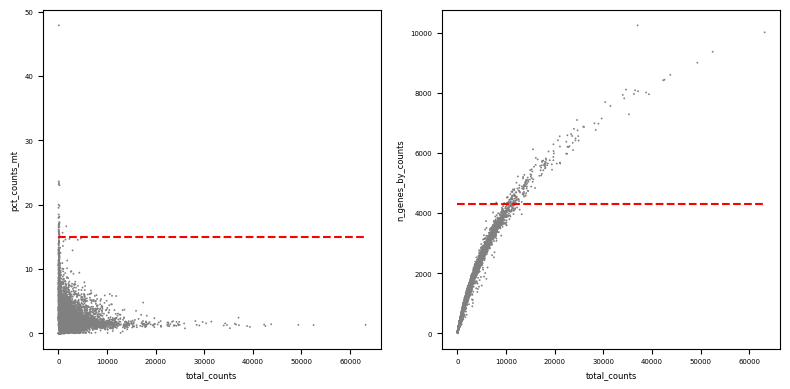

In [19]:
import matplotlib.pyplot as plt
mito_filter = 15
n_counts_filter = 4300
# 修改说明: 图尺寸从 (8,4) 调整为 (4,2)，长宽缩小一半 ZG
fig, axs = plt.subplots(ncols = 2, figsize = (8,4))
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt',ax = axs[0], show=False)
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts',ax = axs[1], show = False)
# 修改说明: 字体整体缩小（刻度5，坐标轴与标题6）以匹配更小图尺寸 ZG
for ax in axs:
    ax.tick_params(labelsize=5)
    ax.xaxis.label.set_size(6)
    ax.yaxis.label.set_size(6)
    ax.title.set_size(6)
#draw horizontal red lines indicating thresholds.
axs[0].hlines(y = mito_filter, xmin = 0, xmax = max(adata.obs['total_counts']), color = 'red', ls = 'dashed')
axs[1].hlines(y = n_counts_filter, xmin = 0, xmax = max(adata.obs['total_counts']), color = 'red', ls = 'dashed')
fig.tight_layout()
plt.show()


在scanpy的官方教程中，高计数的细胞被认为是双细胞进而过滤，所以我们绘制了两条红线，

但在我们的教程中，对于双细胞我们将采用其他方法进行过滤，

所以我们只需要对一些低表达的细胞进行质控，

比如nUMI小于500的细胞，

比如detected_gene小于250的细胞，线粒体基因的计数比例不超过15%。但这个过滤我们要在双细胞过滤完后再进行。

In [20]:
# Original QC plot
n0 = adata.shape[0]
print(f'Original cell number: {n0}')

Original cell number: 16934


3. 双细胞的过滤
双细胞被定义为在相同的细胞条形码（barcode）下进行测序的两个细胞，例如，如果它们被捕获在同一个液滴（droplet）中。
<!-- <div style="color: crimson;"> --> 
<!-- starts an HTML comment --> ends an HTML comment

This will comment out the entire <div> tag, preventing it from being rendered in the output.

<div style="color: lightgreen;">
这也是为什么我们一直使用barcode而不是cells的原因。双细胞由同型（homotypic）与异型（heterotypic）所构成

</div>

<div style="color: yellow;">
同型：同型通常被认为是不影响下游分析的，因为其是由一类相同的细胞中的两个所构成，所以这部分细胞不是我们所需要过滤的对象

</div>

<div style="color: skyblue"> # LightCoral
异型：异型通常是由来自两类不同的细胞所构成的，异型的存在会使得我们后续的细胞分类出现错误，因为其独特的数据分布特征。

</div>

<div style="color: salmon;">
我们可以通过人工构建双细胞进行模拟识别，以排除异型的存在。在本教程中，我们将使用scrublet来完成双细胞的识别。

</div>

In [21]:
print('Begin of post doublets removal and QC plot')
sc.external.pp.scrublet(adata, random_state=112)
adata = adata[adata.obs['predicted_doublet']==False, :].copy()
n1 = adata.shape[0]
print(f'Cells retained after scrublet: {n1}, {n0-n1} removed.')
print(f'End of post doublets removal and QC plots.')

Begin of post doublets removal and QC plot
Cells retained after scrublet: 16933, 1 removed.
End of post doublets removal and QC plots.


4. 手动/自动过滤低质量读数细胞
在第二小节我们介绍了低质量读数的细胞的过滤思想，在本小节中，我们将演示手动与自动过滤低质量读书的细胞的步骤。我们首先将adata复制成两份


4.1 手动过滤低质量读数的细胞¶
我们首先定义一个过滤字典：tresh={'mito_perc': 0.15, 'nUMIs': 500, 'detected_genes': 250}，接着，我们使用该过滤字典完成过滤操作

我们需要对数据取保留的细胞的交集

In [22]:
adata_manual=adata.copy()
adata_auto=adata.copy()

In [ ]:
import numpy as np
tresh={'mito_perc': 0.15, 'nUMIs': 500, 'detected_genes': 250} # 用户自定义阀值

adata_manual.obs['passing_mt'] = adata_manual.obs['mito_perc'] < tresh['mito_perc']
adata_manual.obs['passing_nUMIs'] = adata_manual.obs['nUMIs'] > tresh['nUMIs']
adata_manual.obs['passing_ngenes'] = adata_manual.obs['detected_genes'] > tresh['detected_genes']

print(f'Lower treshold, nUMIs: {tresh["nUMIs"]}; filtered-out-cells: {n1-np.sum(adata_manual.obs["passing_nUMIs"])}')
print(f'Lower treshold, n genes: {tresh["detected_genes"]}; filtered-out-cells: {n1-np.sum(adata_manual.obs["passing_ngenes"])}')
print(f'Lower treshold, mito %: {tresh["mito_perc"]}; filtered-out-cells: {n1-np.sum(adata_manual.obs["passing_mt"])}')

Lower treshold, nUMIs: 500; filtered-out-cells: 2884
Lower treshold, n genes: 250; filtered-out-cells: 1104
Lower treshold, mito %: 0.15; filtered-out-cells: 33


In [24]:
QC_test = (adata_manual.obs['passing_mt']) & (adata_manual.obs['passing_nUMIs']) & (adata_manual.obs['passing_ngenes'])
removed = QC_test.loc[lambda x : x == False]
print(f'Total cell filtered out with this last  QC (and its chosen options): {n1-np.sum(QC_test)}')
adata_manual = adata_manual[QC_test, :].copy()
n2 = adata_manual.shape[0]
    
# Store cleaned adata
print(f'Cells retained after scrublet and filtering: {n2}, {n0-n2} removed.')

Total cell filtered out with this last  QC (and its chosen options): 2887
Cells retained after scrublet and filtering: 14046, 2888 removed.



自此，我们完成了污染去除，但是，我们还需要过滤掉一些从基因和细胞层面低计数的细胞/基因

In [25]:
# Last gene and cell filter
sc.pp.filter_cells(adata_manual, min_genes=200)
sc.pp.filter_genes(adata_manual, min_cells=3)

adata_manual

AnnData object with n_obs × n_vars = 14046 × 28777
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'


4.2 自动过滤低质量读数的细胞
即使是自动过滤，我们也得首先设定好基础阈值，即tresh={'mito_perc': 0.15, 'nUMIs': 500, 'detected_genes': 250}，我们在omicverse里，预先设定好了ov.pp._qc.mads和ov.pp._qc.mads_test两个函数，来计算MAD值。

In [26]:
adata_auto.obs['passing_mt'] = adata_auto.obs['mito_perc'] < tresh['mito_perc']
adata_auto.obs['passing_nUMIs'] = ov.pp._qc.mads_test(adata_auto.obs, 'nUMIs', nmads=5, lt=tresh)
adata_auto.obs['passing_ngenes'] = ov.pp._qc.mads_test(adata_auto.obs, 'detected_genes', nmads=5, lt=tresh)  

nUMIs_t = ov.pp._qc.mads(adata_auto.obs, 'nUMIs', nmads=5, lt=tresh)
n_genes_t = ov.pp._qc.mads(adata_auto.obs, 'detected_genes', nmads=5, lt=tresh)
print(f'Tresholds used, nUMIs: ({nUMIs_t[0]}, {nUMIs_t[1]}); filtered-out-cells: {n1-np.sum(adata_auto.obs["passing_nUMIs"])}')
print(f'Tresholds used, n genes: ({n_genes_t[0]}, {n_genes_t[1]}); filtered-out-cells: {n1-np.sum(adata_auto.obs["passing_ngenes"])}')
print(f'Lower treshold, mito %: {tresh["mito_perc"]}; filtered-out-cells: {n1-np.sum(adata_auto.obs["passing_mt"])}')

Tresholds used, nUMIs: (500, 4241.0); filtered-out-cells: 4400
Tresholds used, n genes: (250, 2622.0); filtered-out-cells: 2211
Lower treshold, mito %: 0.15; filtered-out-cells: 33


同理，我们对需要保留的细胞取交集

In [ ]:
QC_test = (adata_auto.obs['passing_mt']) & (adata_auto.obs['passing_nUMIs']) & (adata_auto.obs['passing_ngenes']) # intersection 
removed = QC_test.loc[lambda x : x == False]
print(f'Total cell filtered out with this last  QC (and its chosen options): {n1-np.sum(QC_test)}')
adata_auto = adata_auto[QC_test, :].copy()
n2 = adata_auto.shape[0]
    
# Store cleaned adata
print(f'Cells retained after scrublet and filtering: {n2}, {n0-n2} removed.')

Total cell filtered out with this last  QC (and its chosen options): 4403
Cells retained after scrublet and filtering: 12530, 4404 removed.



自此，我们完成了污染去除，但是，我们还需要过滤掉一些从基因和细胞层面低计数的细胞/基因

In [28]:
# Last gene and cell filter
sc.pp.filter_cells(adata_auto, min_genes=200)
sc.pp.filter_genes(adata_auto, min_cells=3)

adata_auto

AnnData object with n_obs × n_vars = 12530 × 26821
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'


我们会发现，自动过滤会比手动过滤去除掉更多的细胞，这是因MAD的识别完全从数据的角度出发，去除了离群的值，但是我们手动过滤没有对离群的值进行过滤，而是全部保留。当然，在omicverse中，我们提供了ov.pp.qc函数来完成质控的所有步骤。该函数的参数如下：

mode: 我们可以指定为'seurat'或'mads',如果为seurat，那么则是执行上面的手动过滤步骤，如果是mads，则是自动过滤步骤
min_cells: 一个基因最少在多少个细胞中表达，如果设定为3，那么意味着表达少于3个细胞的基因都将被过滤掉
min_genes: 一个细胞最少表达多少个基因，如果设定为200，那么意味着表达量小于200的细胞都将被过滤掉
nmads: MADs的倍数，前面有阐述，默认5倍为离群值
tresh=None
如果tresh==None，那么其自动设置为{'mito_perc': 0.15, 'nUMIs': 500, 'detected_genes': 250}

In [29]:
adata=ov.pp.qc(adata,
         tresh={'mito_perc': 0.05, 'nUMIs': 500, 'detected_genes': 250})
adata

🖥️ Using CPU mode for QC...

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 103                │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 12                 │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range (Min - Max)       │
   ├─────────────────────

AnnData object with n_obs × n_vars = 13713 × 28707
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes', 'doublet_score', 'predicted_doublet', 'ribo_perc', 'hb_perc', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU'

5. 环境 RNA 的校正
注：本节可能会导致计数矩阵不为整数，使得部分包失效，所以该分析除非你很明确环境RNA的干扰十分严重，不然我认为是可以被跳过的。



对于基于液滴的单细胞 RNA-seq 实验，一定数量的背景 mRNA 存在于稀释液中，与细胞一起分布在液滴中，并随之测序。这样做的最终结果是产生一种背景污染，这种污染表现的不是液滴中所含细胞的表达，而是包含细胞的溶液。

基于液滴的 scRNA-seq 为多个细胞的基因产生独特的分子标识符(UMI)计数，目的是确定每个基因和每个细胞的分子数量。它假设每个液滴都含有来自单个细胞的 mRNA。重复，空液滴和无细胞 RNA 可以打破这一假设。无细胞的 mRNA 分子代表存在于稀释液中的背景 mRNA。这些分子沿着液滴分布，并与它们一起测序。输入溶液中这种无细胞 mRNA 的污染通常被称为细胞溶解产生的“soup”。

无细胞的 mRNA 分子，也被称为环境 RNA，可以混淆观察到的计数的数量，可以被看作是背景污染。对于无细胞 mRNA，纠正基于液滴的 scRNA-seq 数据集非常重要，因为它可能会扭曲我们下游分析中数据的解释。通常，每个输入解决方案的“汤”都不相同，并且取决于数据集中各个单元格之间的表达式模式.

在这里，我们推荐使用soupX包来完成环境RNA的校正，由于环境RNA的校正需要用到raw_feature_bc_matrix文件，该文件大部分文章都不会上传到公开数据集，所以感兴趣的读者可以自行研究soupX的教程。或者从单细胞最佳实践的英文版教程中完成该分析：https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html